# California Housing Cost

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import fetch_california_housing

In [3]:
housing = fetch_california_housing()
print(housing.data.shape, housing.target.shape)
print(housing.feature_names)
print(housing.target)

(20640, 8) (20640,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [4]:
print(housing.DESCR)


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [5]:
from sklearn.model_selection import train_test_split
X = housing.data
y = housing.target

print("X=", X)
print("y=", y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("train:", X_train.shape, y_train.shape)
print("test:", X_test.shape, y_test.shape)

X= [[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]
y= [4.526 3.585 3.521 ... 0.923 0.847 0.894]
train: (16512, 8) (16512,)
test: (4128, 8) (4128,)


In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Simple train with K = 5

In [7]:
knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train, y_train)

# test
new_input = np.array([[8.0, 35.0, 6.5, 1.1, 800.0, 3.0, 34.05, -118.25]])

new_input_scaled = scaler.transform(new_input)

predicted_price = knn_regressor.predict(new_input_scaled)

print(f'Price: {predicted_price[0]:.3f} (x $100,000) ≈ ${predicted_price[0]*100000:,.0f}')


distances, indices = knn_regressor.kneighbors(new_input_scaled)
neighbors_y = y_train.values[indices[0]] if hasattr(y_train, 'values') else y_train[indices[0]]

print('5 hàng xóm gần nhất:', neighbors_y)
print('Trung bình:', neighbors_y.mean())

Price: 4.982 (x $100,000) ≈ $498,161
5 hàng xóm gần nhất: [5.00001 5.00001 5.00001 4.908   5.00001]
Trung bình: 4.981608


## Find optimize K_neighbours

In [8]:
k_values = [i for i in range (1, 31)]
scores = []

for k in k_values:
    knn_regressor = KNeighborsRegressor(k)
    knn_regressor.fit(X_train, y_train)
    y_pred = knn_regressor.predict(X_test)
    score = r2_score(y_test, y_pred)
    scores.append(np.mean(score))
    print(k, round(score, 4))

1 0.4895
2 0.601
3 0.6439
4 0.6586
5 0.67
6 0.6725
7 0.6731
8 0.676
9 0.676
10 0.6783
11 0.6806
12 0.6809
13 0.6823
14 0.6811
15 0.6804
16 0.6787
17 0.6787
18 0.6784
19 0.6781
20 0.6768
21 0.6764
22 0.6759
23 0.6752
24 0.6747
25 0.6745
26 0.6737
27 0.6732
28 0.6717
29 0.6716
30 0.671


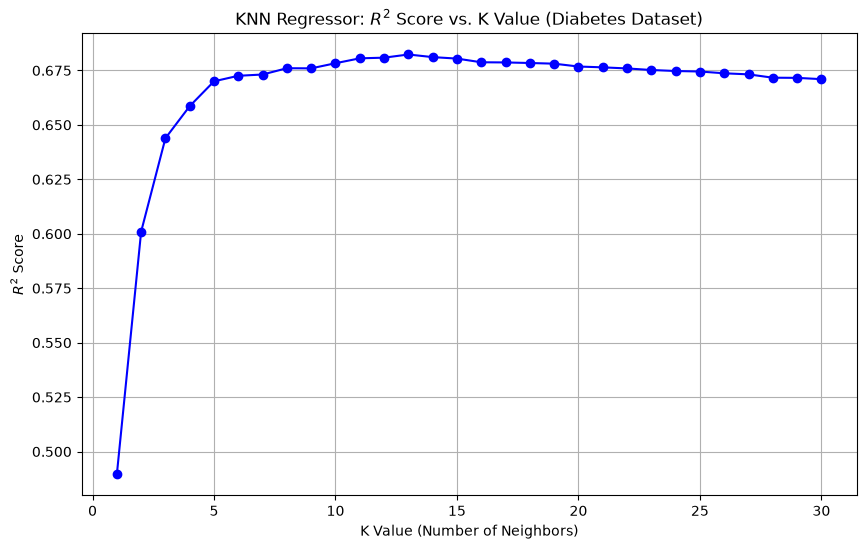

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, scores, marker='o', linestyle='-', color='b')
plt.title('KNN Regressor: $R^2$ Score vs. K Value (Diabetes Dataset)')
plt.xlabel('K Value (Number of Neighbors)')
plt.ylabel('$R^2$ Score')
plt.grid(True)
plt.show()